<a href="https://colab.research.google.com/github/heejulie/-/blob/main/4%ED%9A%8C%EC%B0%A8_ipynb_(%ED%8A%B8%EB%9E%9C%EC%8A%A4%ED%8F%AC%EB%A8%B8_%ED%8C%8C%EC%9D%B4%ED%86%A0%EC%B9%98%EB%A1%9C_%EB%A7%8C%EB%93%A4%EA%B8%B0).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PyTorch Transformer**

## **Transformer(트랜스포머)**

현대 자연어처리 모델들 대부분의 뼈대가 되는 아키텍쳐  
논문: [Attention is all you need - Vaswani et al., 2017.](https://arxiv.org/abs/1706.03762)

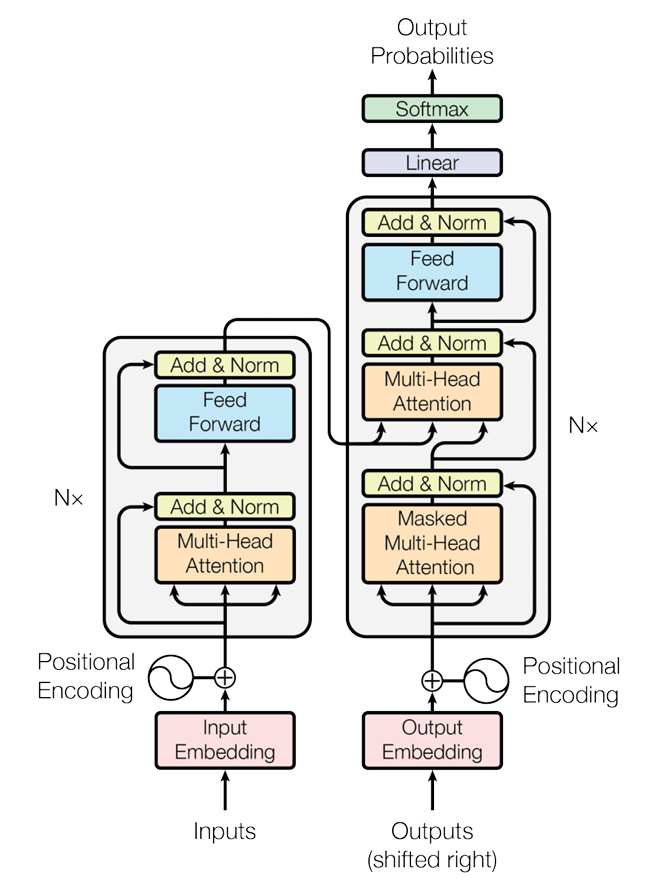

### Hyperparameters

$d_{model} = 512$
입출력의 길이이자 임베딩 및 은닉 차원수

$d_{ff} = 2048$  
**F**eed-**F**orward network의 은닉 차원 수  

$d_k = 64$  
멀티헤드 어텐션에서, 한 헤드에서 사용할 벡터의 차원 수  

$h = 8$  
멀티헤드 어텐션에서, 어텐션 헤드의 수  

$N = 6$  
인코더/디코더 블록의 수  
  

### 개념 정리

#### **Self-Attention(셀프 어텐션)**  

$Q$, $K$, $V$의 출처가 같은 어텐션  


이전 Seq2Seq의 Attention에서는...  
- $Q$: 디코더의 은닉 상태
- $K$, $V$: 인코더의 은닉 상태

#### **Masked Self-Attention**  

디코더가 순서 정보를 무시하고 뒤 단어를 참고할 수 없도록 마스킹하는(가리는) 어텐션  

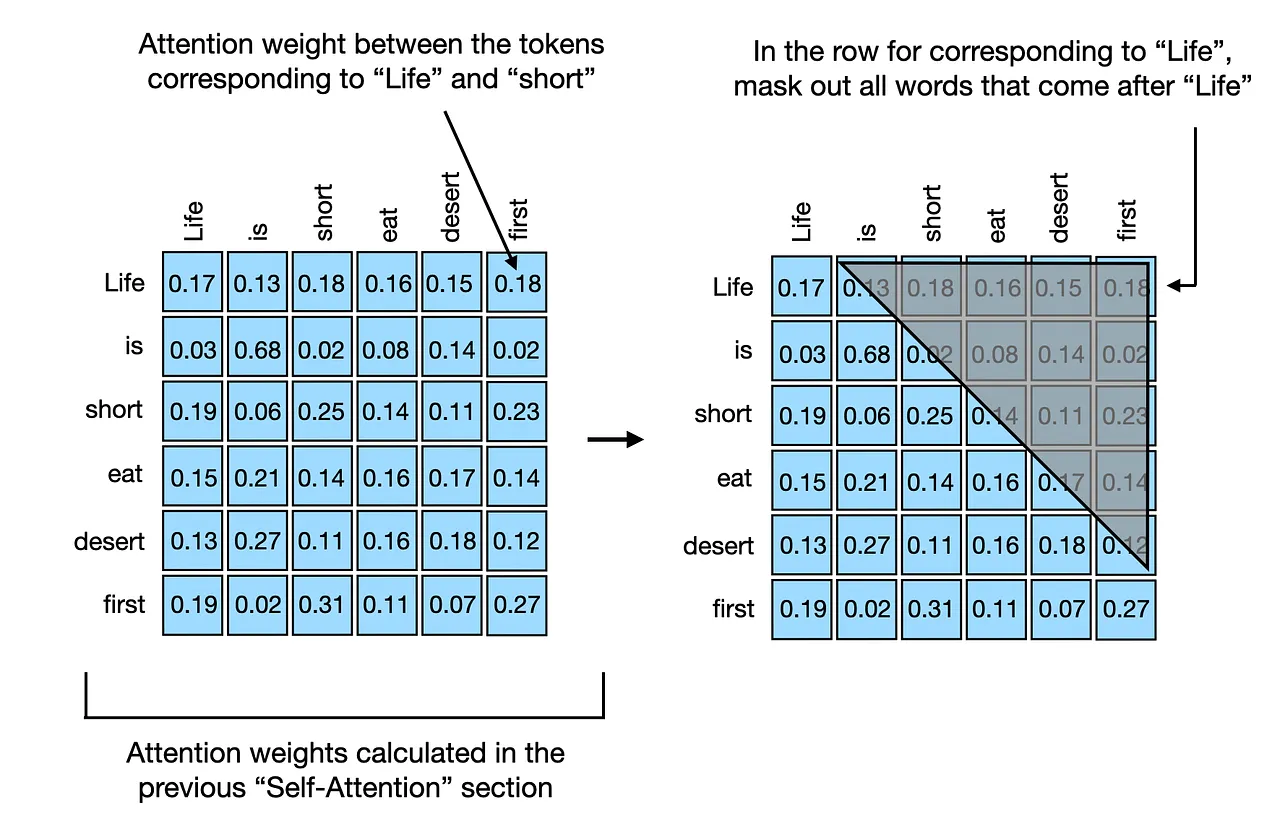

- RNN: 디코더가 시점 t에서 시점 t+1 이후의 단어들을 참고할 수 없다.  
- Transformer: 모든 시점의 단어들을 병렬 처리하므로, 뭔가 수를 쓰지 않으면 디코더가 뒤 단어를 컨닝할 수 있다.  

1. 어텐션 분포를 구하기 전에, 마스킹 할 부분의 어텐션 점수를 -∞로 바꿔치기 한다  
2. $softmax$를 거치고 나면, 1에서 마스킹 한 부분들은 0이 된다.  

출처: [magazine.sebastianraschka.com](https://magazine.sebastianraschka.com/p/understanding-and-coding-self-attention)

#### **Multi-Head Attention(멀티헤드 어텐션)**  

여러 헤드(head)로 나누어 동시에
연산하는 어텐션  

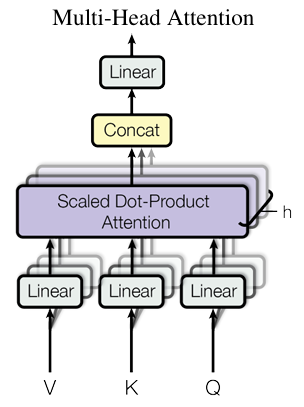

1. $d_{model}$ 차원의 입력 벡터 $Q$, $K$, $V$를 각각 행렬
$W^Q_i$,$W^K_i$, $W^V_i$ 과 곱해, $d_k$ 차원의 벡터들을 얻는다.
2. 1에서 구한 벡터들로 어텐션 연산을 해서 $d_k$ 차원의 벡터를 얻는다.
3. 1, 2를 $h$개의 헤드에서 ($i$를 바꿔가며) 각각 수행한다.  
4. $h$개의 $d_k$ 차원의 벡터를 이어붙여, $d_{model}$ 차원의 벡터를 얻는다.

#### **Scaled Dot-Product Attention**  

중간에 특정 값으로 한 번 나눠주는 Dot-Product Attention  

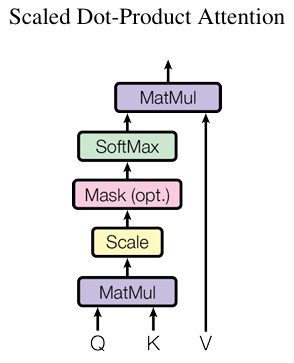

- Dot-Pruduct Attention  
$Attention(Q, K, V) = softmax(QK^T)V$

- Scaled Dot-Product Attention  
$Attention(Q, K, V) = softmax(\cfrac{QK^T}{\sqrt{d_k}})V$  
※ Transformer 논문에서 사용한 값이 $\sqrt{d_k}$일 뿐, 다른 값으로 scaling할 수도 있다.

#### **Residual Connection(잔차 연결)**  

Sublayer를 지나기 전의 값을 지난 후의 값에 더해주는 것  

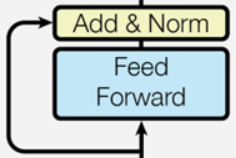  

- Sublayer를 지나기 전의 값을 빼두었다가, 층 정규화 전에 더해준다.
- Sublayer를 거치면서 이전의 정보가 손실되는 것을 방지

#### **Layer Normalization(층 정규화)**  

각 샘플 내의 feature들의 평균과 표준편차를 활용하는 정규화  

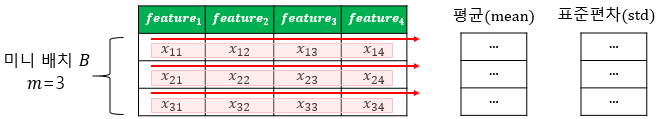  

출처: [위키독스 - PyTorch로 시작하는 딥 러닝 입문](https://wikidocs.net/61271)

### Positional Encoding

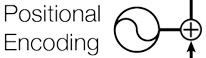  

단어의 문장 내 위치 정보를 알려주는 벡터

RNN의 장점: 시점에 따라 순서대로 입력받으므로, 순서가 중요한 데이터를 잘 처리한다.
Transformer의 병렬 처리: 임베딩들을 순서대로 입력받지 않고, 한꺼번에 입력받는다.  

**Q**. 그러면 단어들의 문장 내 순서는 무시하는가?  
**A**. 각 위치마다 고유한 값을 가지는 벡터를 임베딩에 더해서 반영한다.  
  
-----------

$PE_{(pos, 2i)} = sin(pos/10000^{2i/d_{model}})$  
$PE_{(pos, 2i+1)} = cos(pos/10000^{2i/d_{model}})$  
- $pos$: 문장 내 단어의 위치  
- 인덱스가 짝수/홀수일 때, $sin$과 $cos$를 번갈아 사용한다
-----------  

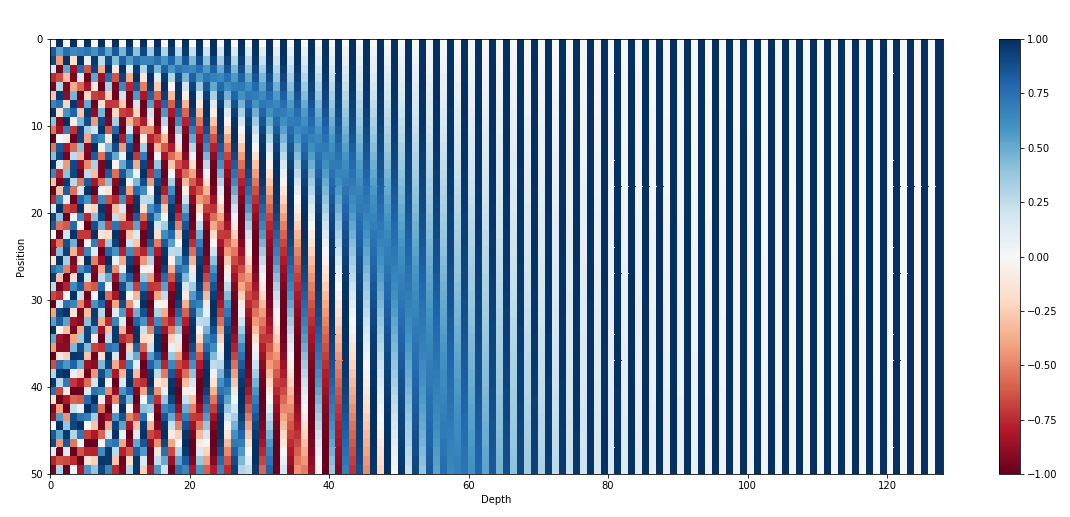  

50($pos$) × 128($d_{model}$)의 PE 행렬  
출처: [kazemnejad.com](https://kazemnejad.com/blog/transformer_architecture_positional_encoding/)

### Encoder

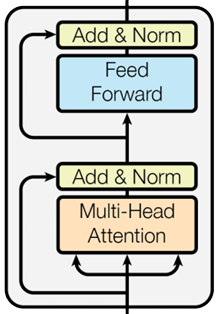  

위와 같은 인코더 블록 × $N$으로 이루어진 인코더

인코더 블록의 구성  
- Multi-Head Self-Attention
- Position-wise FFNN
  - activation: ReLU  

  \+ Residual Connection  
  \+ Layer Normalization  

※ Position-wise FFNN: 비선형성을 추가하는 역할, shallow network
- input_dim/output_dim: $d_{model}$
- hidden_dim: $d_{ff}$

###Decoder

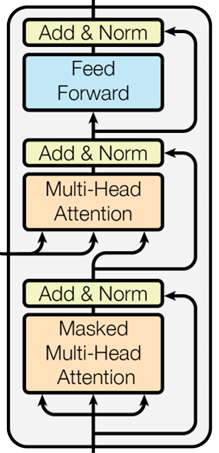  

위와 같은 디코더 블록 × $N$으로 이루어진 디코더

디코더 블록의 구성
- Masked Multi-Head Self-Attention
- Multi-Head Encoder-Decoder(Cross) Attention
  - ※ $K$,$V$의 출처가 인코더이다.
- Position-wise FFNN
  - activation: ReLU  

  \+ Residual Connection  
  \+ Layer Normalization

### Output Layer

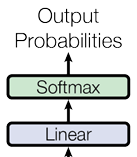  

어떤 단어를 출력할 것인지 결정하는, 디코더의 마지막 층

이전 Seq2Seq 디코더의 출력층과 동일한 역할 수행
1. 선형 분류기를 통해 vocab 크기 차원의 벡터를 얻는다.
2. $softmax$를 적용해 확률 분포(0과 1사이의 값)로 변환한다.

### ※ 어텐션 3종 정리  

1. 인코더의 Multi-Head Self-Attention
2. 디코더의 Masked Multi-Head Self-Attention  
3. 디코더의 Multi-Head Cross Attention

## **PyTorch로 구현하기**

In [ ]:
!pip install datasets evaluate --upgrade
!python -m spacy download de_core_news_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.8.5
    Uninstalling datasets-4.8.5:
      Successfully uninstalled datasets-4.8.5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 45.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import random
import numpy as np
from tqdm.auto import tqdm
from itertools import chain
from collections import Counter

import spacy
import datasets
import evaluate
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [ ]:
# Reproducibility를 위한 시드 고정

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

In [ ]:
# torchtext를 대체하는 class

class Vocab():

    def __init__(self):
        self.stoi = None
        self.itos = None

    def build_vocab_from_iterator(self, iterator, min_freq=1, specials=[]):
        freq_dict_sorted = Counter(chain(*iterator)).most_common()

        i = 0
        self.stoi = {}
        self.itos = specials.copy()

        for special in specials:
            self.stoi[special] = i
            i += 1

        for pair in tqdm(freq_dict_sorted, desc="Building Vocab"):
            word, freq = pair
            if word not in specials and freq >= min_freq:
                self.stoi[word] = i
                self.itos.append(word)
                i += 1

        assert len(self.stoi) == len(self.itos)

    def __len__(self):
        return len(self.itos)

    def __contains__(self, key):
        return key in self.stoi

    def __getitem__(self, key):
        if key not in self.stoi:
          return self.stoi["<unk>"]
        return(self.stoi[key])

    def get_stoi(self):
        return self.stoi

    def get_itos(self):
        return self.itos

    def lookup_tokens(self, indices):
        return [self.itos[index] for index in indices]

    def lookup_indices(self, tokens):
        return [self.stoi[token] if token in self.stoi else self.stoi["<unk>"] for token in tokens]

### **데이터 준비하기**

**Multi30k**  
[HuggingFace 🤗 - bentrevett/multi30k](https://huggingface.co/datasets/bentrevett/multi30k)

- 요약: 텍스트를 다른 언어로 번역
- 언어: 독일어 → 영어
- 수량: Train 29,000건 / Valid 1,014건 / Test 1,000건

In [ ]:
data = datasets.load_dataset("bentrevett/multi30k")
data # datasets.DatasetDict

README.md:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/4.60M [00:00<?, ?B/s]

val.jsonl:   0%|          | 0.00/164k [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/156k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['en', 'de'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['en', 'de'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['en', 'de'],
        num_rows: 1000
    })
})

In [ ]:
train_data, valid_data, test_data = (
    data["train"],
    data["validation"],
    data["test"],
)

In [ ]:
train_data[0] # 데이터 예시

{'en': 'Two young, White males are outside near many bushes.',
 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.'}

In [ ]:
# 토크나이저(Tokenizer)

en_nlp = spacy.load("en_core_web_sm")
de_nlp = spacy.load("de_core_news_sm")

string = "What a lovely day it is today!"

[token.text for token in en_nlp.tokenizer(string)]

['What', 'a', 'lovely', 'day', 'it', 'is', 'today', '!']

※ 배치로 묶어서 시퀀스를 처리하려면, 배치 내 모든 시퀀스의 길이가 같아야 한다.

**Padding**  
시퀀스들 뒤에 토큰이나 정수를 추가해 특정 길이로 맞춘다.  

**Truncation**  
특정 길이를 넘는 시퀀스들을, 해당 길이에 맞춰 자른다.

In [ ]:
def tokenize_example(example, max_length, lower, sos_token, eos_token):

    # Truncation
    en_tokens = [token.text for token in en_nlp.tokenizer(example["en"])][:max_length]
    de_tokens = [token.text for token in de_nlp.tokenizer(example["de"])][:max_length]

    # 소문자화
    if lower:
        en_tokens = [token.lower() for token in en_tokens]
        de_tokens = [token.lower() for token in de_tokens]

    # 특수 토큰 추가
    en_tokens = [sos_token] + en_tokens + [eos_token]
    de_tokens = [sos_token] + de_tokens + [eos_token]

    return {"en_tokens": en_tokens, "de_tokens": de_tokens}

In [ ]:
max_length = 1_000
lower = True
sos_token = "<sos>"
eos_token = "<eos>"

fn_kwargs = {
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}

# Dataset.map(function): function을 Dataset에 일괄 적용
train_data = train_data.map(tokenize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(tokenize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(tokenize_example, fn_kwargs=fn_kwargs)

Map:   0%|          | 0/29000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1014 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
min_freq = 2
unk_token = "<unk>" # Unknown 토큰
pad_token = "<pad>" # Padding 토큰

special_tokens = [
    unk_token,
    pad_token,
    sos_token,
    eos_token,
]

en_vocab = Vocab()
en_vocab.build_vocab_from_iterator(
    train_data["en_tokens"],
    min_freq=min_freq,
    specials=special_tokens,
)

de_vocab = Vocab()
de_vocab.build_vocab_from_iterator(
    train_data["de_tokens"],
    min_freq=min_freq,
    specials=special_tokens,
)

Building Vocab:   0%|          | 0/9795 [00:00<?, ?it/s]

Building Vocab:   0%|          | 0/18667 [00:00<?, ?it/s]

In [ ]:
len(en_vocab), len(de_vocab)

(5893, 7853)

In [ ]:
assert en_vocab[unk_token] == de_vocab[unk_token]
assert en_vocab[pad_token] == de_vocab[pad_token]

unk_index = en_vocab[unk_token]
pad_index = en_vocab[pad_token]

In [ ]:
tokens = ["i", "love", "watching", "crime", "shows"]
en_vocab.lookup_indices(tokens)

[951, 2217, 171, 0, 815]

In [ ]:
en_vocab.lookup_tokens(en_vocab.lookup_indices(tokens))

['i', 'love', 'watching', '<unk>', 'shows']

In [ ]:
# 정수 인코딩

def numericalize_example(example):
    en_ids = en_vocab.lookup_indices(example["en_tokens"])
    de_ids = de_vocab.lookup_indices(example["de_tokens"])
    return {"en_ids": en_ids, "de_ids": de_ids}

train_data = train_data.map(numericalize_example)
valid_data = valid_data.map(numericalize_example)
test_data = test_data.map(numericalize_example)

train_data[0] # 확인

Map:   0%|          | 0/29000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1014 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

{'en': 'Two young, White males are outside near many bushes.',
 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.',
 'en_tokens': ['<sos>',
  'two',
  'young',
  ',',
  'white',
  'males',
  'are',
  'outside',
  'near',
  'many',
  'bushes',
  '.',
  '<eos>'],
 'de_tokens': ['<sos>',
  'zwei',
  'junge',
  'weiße',
  'männer',
  'sind',
  'im',
  'freien',
  'in',
  'der',
  'nähe',
  'vieler',
  'büsche',
  '.',
  '<eos>'],
 'en_ids': [2, 16, 24, 15, 25, 774, 17, 57, 80, 202, 1305, 5, 3],
 'de_ids': [2, 18, 26, 253, 30, 84, 20, 88, 7, 15, 110, 5374, 3099, 4, 3]}

In [ ]:
data_type = "torch"
format_columns = ["en_ids", "de_ids"]

# Dataset.with_format(type, columns): Dataset의 columns 안의 데이터를 type 형태로 변경
train_data = train_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True
)

valid_data = valid_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

test_data = test_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

train_data[0] # 확인

{'en_ids': tensor([   2,   16,   24,   15,   25,  774,   17,   57,   80,  202, 1305,    5,
            3]),
 'de_ids': tensor([   2,   18,   26,  253,   30,   84,   20,   88,    7,   15,  110, 5374,
         3099,    4,    3]),
 'en': 'Two young, White males are outside near many bushes.',
 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.',
 'en_tokens': ['<sos>',
  'two',
  'young',
  ',',
  'white',
  'males',
  'are',
  'outside',
  'near',
  'many',
  'bushes',
  '.',
  '<eos>'],
 'de_tokens': ['<sos>',
  'zwei',
  'junge',
  'weiße',
  'männer',
  'sind',
  'im',
  'freien',
  'in',
  'der',
  'nähe',
  'vieler',
  'büsche',
  '.',
  '<eos>']}

In [ ]:
def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_en_ids = [example["en_ids"] for example in batch]
        batch_de_ids = [example["de_ids"] for example in batch]
        batch_en_ids = nn.utils.rnn.pad_sequence(batch_en_ids, batch_first=True, padding_value=pad_index)
        batch_de_ids = nn.utils.rnn.pad_sequence(batch_de_ids, batch_first=True, padding_value=pad_index)
        batch = {
            "en_ids": batch_en_ids,
            "de_ids": batch_de_ids,
        }
        return batch

    return collate_fn

In [ ]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
    )
    return data_loader

In [ ]:
batch_size = 128 # Hyperparameter

train_data_loader = get_data_loader(train_data, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_data, batch_size, pad_index)
test_data_loader = get_data_loader(test_data, batch_size, pad_index)

### **모델 구축하기**

In [ ]:
class MultiHeadAttentionLayer(nn.Module):
    def __init__(self, hid_dim, n_heads, dropout, device):
        super().__init__()

        assert hid_dim % n_heads == 0

        self.hid_dim = hid_dim
        self.n_heads = n_heads
        self.head_dim = hid_dim // n_heads

        self.fc_q = nn.Linear(hid_dim, hid_dim)
        self.fc_k = nn.Linear(hid_dim, hid_dim)
        self.fc_v = nn.Linear(hid_dim, hid_dim)

        self.fc_o = nn.Linear(hid_dim, hid_dim)

        self.dropout = nn.Dropout(dropout)

        self.scale = torch.sqrt(torch.FloatTensor([self.head_dim])).to(device)

    def forward(self, query, key, value, mask = None):

        batch_size = query.shape[0]

        #query = [batch size, query len, hid dim]
        #key = [batch size, key len, hid dim]
        #value = [batch size, value len, hid dim]

        Q = self.fc_q(query)
        K = self.fc_k(key)
        V = self.fc_v(value)

        #Q = [batch size, query len, hid dim]
        #K = [batch size, key len, hid dim]
        #V = [batch size, value len, hid dim]

        Q = Q.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        K = K.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        V = V.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)

        #Q = [batch size, n heads, query len, head dim]
        #K = [batch size, n heads, key len, head dim]
        #V = [batch size, n heads, value len, head dim]

        energy = torch.matmul(Q, K.permute(0, 1, 3, 2)) / self.scale

        #energy = [batch size, n heads, query len, key len]

        if mask is not None:
            energy = energy.masked_fill(mask == 0, -1e10)

        attention = torch.softmax(energy, dim = -1)

        #attention = [batch size, n heads, query len, key len]

        x = torch.matmul(self.dropout(attention), V)

        #x = [batch size, n heads, query len, head dim]

        x = x.permute(0, 2, 1, 3).contiguous()

        #x = [batch size, query len, n heads, head dim]

        x = x.view(batch_size, -1, self.hid_dim)

        #x = [batch size, query len, hid dim]

        x = self.fc_o(x)

        #x = [batch size, query len, hid dim]

        return x, attention

In [ ]:
class PositionwiseFeedforwardLayer(nn.Module):
    def __init__(self, hid_dim, pf_dim, dropout):
        super().__init__()

        self.fc_1 = nn.Linear(hid_dim, pf_dim)
        self.fc_2 = nn.Linear(pf_dim, hid_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        #x = [batch size, seq len, hid dim]

        x = self.dropout(torch.relu(self.fc_1(x)))

        #x = [batch size, seq len, pf dim]

        x = self.fc_2(x)

        #x = [batch size, seq len, hid dim]

        return x

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self,
                 hid_dim,
                 n_heads,
                 pf_dim,
                 dropout,
                 device):
        super().__init__()

        self.self_attn_layer_norm = nn.LayerNorm(hid_dim)
        self.ff_layer_norm = nn.LayerNorm(hid_dim)
        self.self_attention = MultiHeadAttentionLayer(hid_dim, n_heads, dropout, device)
        self.positionwise_feedforward = PositionwiseFeedforwardLayer(hid_dim,
                                                                     pf_dim,
                                                                     dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask):

        #src = [batch size, src len, hid dim]
        #src_mask = [batch size, 1, 1, src len]

        #self attention
        _src, _ = self.self_attention(src, src, src, src_mask)

        #dropout, residual connection and layer norm
        src = self.self_attn_layer_norm(src + self.dropout(_src))

        #src = [batch size, src len, hid dim]

        #positionwise feedforward
        _src = self.positionwise_feedforward(src)

        #dropout, residual and layer norm
        src = self.ff_layer_norm(src + self.dropout(_src))

        #src = [batch size, src len, hid dim]

        return src

In [ ]:
class Encoder(nn.Module):
    def __init__(self,
                 input_dim,
                 hid_dim,
                 n_layers,
                 n_heads,
                 pf_dim,
                 dropout,
                 device,
                 max_length = 1_000):
        super().__init__()

        self.device = device

        self.tok_embedding = nn.Embedding(input_dim, hid_dim)
        self.pos_embedding = nn.Embedding(max_length, hid_dim)

        self.layers = nn.ModuleList([EncoderLayer(hid_dim,
                                                  n_heads,
                                                  pf_dim,
                                                  dropout,
                                                  device)
                                     for _ in range(n_layers)])

        self.dropout = nn.Dropout(dropout)

        self.scale = torch.sqrt(torch.FloatTensor([hid_dim])).to(device)

    def forward(self, src, src_mask):

        #src = [batch size, src len]
        #src_mask = [batch size, 1, 1, src len]

        batch_size = src.shape[0]
        src_len = src.shape[1]

        pos = torch.arange(0, src_len).unsqueeze(0).repeat(batch_size, 1).to(self.device)

        #pos = [batch size, src len]

        src = self.dropout((self.tok_embedding(src) * self.scale) + self.pos_embedding(pos))

        #src = [batch size, src len, hid dim]

        for layer in self.layers:
            src = layer(src, src_mask)

        #src = [batch size, src len, hid dim]

        return src

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self,
                 hid_dim,
                 n_heads,
                 pf_dim,
                 dropout,
                 device):
        super().__init__()

        self.self_attn_layer_norm = nn.LayerNorm(hid_dim)
        self.enc_attn_layer_norm = nn.LayerNorm(hid_dim)
        self.ff_layer_norm = nn.LayerNorm(hid_dim)
        self.self_attention = MultiHeadAttentionLayer(hid_dim, n_heads, dropout, device)
        self.encoder_attention = MultiHeadAttentionLayer(hid_dim, n_heads, dropout, device)
        self.positionwise_feedforward = PositionwiseFeedforwardLayer(hid_dim,
                                                                     pf_dim,
                                                                     dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, trg, enc_src, trg_mask, src_mask):

        #trg = [batch size, trg len, hid dim]
        #enc_src = [batch size, src len, hid dim]
        #trg_mask = [batch size, 1, trg len, trg len]
        #src_mask = [batch size, 1, 1, src len]

        #self attention
        _trg, _ = self.self_attention(trg, trg, trg, trg_mask)

        #dropout, residual connection and layer norm
        trg = self.self_attn_layer_norm(trg + self.dropout(_trg))

        #trg = [batch size, trg len, hid dim]

        #encoder attention
        _trg, attention = self.encoder_attention(trg, enc_src, enc_src, src_mask)

        #dropout, residual connection and layer norm
        trg = self.enc_attn_layer_norm(trg + self.dropout(_trg))

        #trg = [batch size, trg len, hid dim]

        #positionwise feedforward
        _trg = self.positionwise_feedforward(trg)

        #dropout, residual and layer norm
        trg = self.ff_layer_norm(trg + self.dropout(_trg))

        #trg = [batch size, trg len, hid dim]
        #attention = [batch size, n heads, trg len, src len]

        return trg, attention

In [ ]:
class Decoder(nn.Module):
    def __init__(self,
                 output_dim,
                 hid_dim,
                 n_layers,
                 n_heads,
                 pf_dim,
                 dropout,
                 device,
                 max_length = 1_000):
        super().__init__()

        self.device = device

        self.tok_embedding = nn.Embedding(output_dim, hid_dim)
        self.pos_embedding = nn.Embedding(max_length, hid_dim)

        self.layers = nn.ModuleList([DecoderLayer(hid_dim,
                                                  n_heads,
                                                  pf_dim,
                                                  dropout,
                                                  device)
                                     for _ in range(n_layers)])

        self.fc_out = nn.Linear(hid_dim, output_dim)

        self.dropout = nn.Dropout(dropout)

        self.scale = torch.sqrt(torch.FloatTensor([hid_dim])).to(device)

    def forward(self, trg, enc_src, trg_mask, src_mask):

        #trg = [batch size, trg len]
        #enc_src = [batch size, src len, hid dim]
        #trg_mask = [batch size, 1, trg len, trg len]
        #src_mask = [batch size, 1, 1, src len]

        batch_size = trg.shape[0]
        trg_len = trg.shape[1]

        pos = torch.arange(0, trg_len).unsqueeze(0).repeat(batch_size, 1).to(self.device)

        #pos = [batch size, trg len]

        trg = self.dropout((self.tok_embedding(trg) * self.scale) + self.pos_embedding(pos))

        #trg = [batch size, trg len, hid dim]

        for layer in self.layers:
            trg, attention = layer(trg, enc_src, trg_mask, src_mask)

        #trg = [batch size, trg len, hid dim]
        #attention = [batch size, n heads, trg len, src len]

        output = self.fc_out(trg)

        #output = [batch size, trg len, output dim]

        return output, attention

In [ ]:
class Transformer(nn.Module):
    def __init__(self,
                 encoder,
                 decoder,
                 src_pad_idx,
                 trg_pad_idx,
                 device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.src_pad_idx = src_pad_idx
        self.trg_pad_idx = trg_pad_idx
        self.device = device

    def make_src_mask(self, src):

        #src = [batch size, src len]

        src_mask = (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)

        #src_mask = [batch size, 1, 1, src len]

        return src_mask

    def make_trg_mask(self, trg):

        #trg = [batch size, trg len]

        trg_pad_mask = (trg != self.trg_pad_idx).unsqueeze(1).unsqueeze(2)

        #trg_pad_mask = [batch size, 1, 1, trg len]

        trg_len = trg.shape[1]

        trg_sub_mask = torch.tril(torch.ones((trg_len, trg_len), device = self.device)).bool()

        #trg_sub_mask = [trg len, trg len]

        trg_mask = trg_pad_mask & trg_sub_mask

        #trg_mask = [batch size, 1, trg len, trg len]

        return trg_mask

    def forward(self, src, trg):

        #src = [batch size, src len]
        #trg = [batch size, trg len]

        src_mask = self.make_src_mask(src)
        trg_mask = self.make_trg_mask(trg)

        #src_mask = [batch size, 1, 1, src len]
        #trg_mask = [batch size, 1, trg len, trg len]

        enc_src = self.encoder(src, src_mask)

        #enc_src = [batch size, src len, hid dim]

        output, attention = self.decoder(trg, enc_src, trg_mask, src_mask)

        #output = [batch size, trg len, output dim]
        #attention = [batch size, n heads, trg len, src len]

        return output, attention

In [ ]:
src_pad_idx = pad_index
trg_pad_idx = pad_index
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(de_vocab)
output_dim = len(en_vocab)
hidden_dim = 256
encoder_layers = 3
decoder_layers = 3
encoder_heads = 8
decoder_heads = 8
encoder_pf_dim = 512
decoder_pf_dim = 512
encoder_dropout = 0.1
decoder_dropout = 0.1

encoder = Encoder(input_dim,
                  hidden_dim,
                  encoder_layers,
                  encoder_heads,
                  encoder_pf_dim,
                  encoder_dropout,
                  device)

decoder = Decoder(output_dim,
                  hidden_dim,
                  decoder_layers,
                  decoder_heads,
                  decoder_pf_dim,
                  decoder_dropout,
                  device)

model = Transformer(encoder, decoder, src_pad_idx, trg_pad_idx, device).to(device)

In [ ]:
# 모델 가중치 초기화

def init_weights(m):
    for name, param in m.named_parameters():
        if "weight" in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        else:
            nn.init.constant_(param.data, 0)


model.apply(init_weights)

Transformer(
  (encoder): Encoder(
    (tok_embedding): Embedding(7853, 256)
    (pos_embedding): Embedding(100, 256)
    (layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (self_attn_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (ff_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (self_attention): MultiHeadAttentionLayer(
          (fc_q): Linear(in_features=256, out_features=256, bias=True)
          (fc_k): Linear(in_features=256, out_features=256, bias=True)
          (fc_v): Linear(in_features=256, out_features=256, bias=True)
          (fc_o): Linear(in_features=256, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (positionwise_feedforward): PositionwiseFeedforwardLayer(
          (fc_1): Linear(in_features=256, out_features=512, bias=True)
          (fc_2): Linear(in_features=512, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
     

In [ ]:
# 훈련되는 parameter 수 출력(모든 parameter가 훈련되지 않을 수 있음)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"The model has {count_parameters(model):,} trainable parameters")

The model has 9,268,741 trainable parameters


### **모델 훈련하기**

In [ ]:
# Optimizer, Loss Function

learning_rate = 5e-4 # Hyperparameter

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
loss_function = nn.CrossEntropyLoss(ignore_index=pad_index)

In [ ]:
# 모델 훈련 함수

def train_fn(
    model, data_loader, optimizer, loss_function, clip, device
):
    model.train()
    epoch_loss = 0
    for i, batch in enumerate(data_loader):
        src = batch["de_ids"].to(device)
        trg = batch["en_ids"].to(device)
        # src = [batch size, src length]
        # trg = [batch size, trg length]
        optimizer.zero_grad()
        output, attention = model(src, trg[:, :-1])
        # output = [batch size, trg len, output dim]
        output_dim = output.shape[-1]
        output = output.contiguous().view(-1, output_dim)
        # output = [(trg length - 1) * batch size, output dim]
        trg = trg[:, 1:].contiguous().view(-1)
        # trg = [(trg length - 1) * batch size]
        loss = loss_function(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(data_loader)

In [ ]:
# 모델 중간 평가 함수

def evaluate_fn(model, data_loader, loss_function, device):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            src = batch["de_ids"].to(device)
            trg = batch["en_ids"].to(device)
        # src = [batch size, src length]
        # trg = [batch size, trg length]
            output, attention = model(src, trg[:, :-1])
            # output = [batch size, trg length, trg vocab size]
            output_dim = output.shape[-1]
            output = output.contiguous().view(-1, output_dim)
            # output = [(trg length - 1) * batch size, output dim]
            trg = trg[:, 1:].contiguous().view(-1)
            # trg = [(trg length - 1) * batch size]
            loss = loss_function(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(data_loader)

In [ ]:
# 모델 훈련

n_epochs = 10
clip = 1.0

best_valid_loss = float("inf")

for epoch in tqdm(range(n_epochs)):
    train_loss = train_fn(
        model,
        train_data_loader,
        optimizer,
        loss_function,
        clip,
        device,
    )
    valid_loss = evaluate_fn(
        model,
        valid_data_loader,
        loss_function,
        device,
    )
    if valid_loss < best_valid_loss: # validation split에 대한 loss가 줄어들 때만 저장
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "transformer-model.pt")
    print(f"\tTrain Loss: {train_loss:7.3f} | Train PPL: {np.exp(train_loss):7.3f}")
    print(f"\tValid Loss: {valid_loss:7.3f} | Valid PPL: {np.exp(valid_loss):7.3f}")

  0%|          | 0/10 [00:00<?, ?it/s]

	Train Loss:   6.432 | Train PPL: 621.593
	Valid Loss:   4.823 | Valid PPL: 124.338
	Train Loss:   4.286 | Train PPL:  72.682
	Valid Loss:   3.842 | Valid PPL:  46.624
	Train Loss:   3.714 | Train PPL:  41.032
	Valid Loss:   3.529 | Valid PPL:  34.103
	Train Loss:   3.450 | Train PPL:  31.510
	Valid Loss:   3.330 | Valid PPL:  27.951
	Train Loss:   3.233 | Train PPL:  25.348
	Valid Loss:   3.141 | Valid PPL:  23.130
	Train Loss:   3.028 | Train PPL:  20.652
	Valid Loss:   2.978 | Valid PPL:  19.654
	Train Loss:   2.847 | Train PPL:  17.239
	Valid Loss:   2.849 | Valid PPL:  17.266
	Train Loss:   2.674 | Train PPL:  14.500
	Valid Loss:   2.699 | Valid PPL:  14.861
	Train Loss:   2.481 | Train PPL:  11.951
	Valid Loss:   2.534 | Valid PPL:  12.608
	Train Loss:   2.281 | Train PPL:   9.784
	Valid Loss:   2.388 | Valid PPL:  10.895


### **모델 평가하기**

In [ ]:
# 훈련한 모델 불러오기

model.load_state_dict(torch.load("transformer-model.pt"))

test_loss = evaluate_fn(model, test_data_loader, loss_function, device)

print(f"| Test Loss: {test_loss:.3f} | Test PPL: {np.exp(test_loss):7.3f} |")

| Test Loss: 2.370 | Test PPL:  10.692 |


In [ ]:
# 모델을 사용하여 번역하는 함수

def translate_sentence(
    sentence,
    model,
    lower,
    device,
    max_output_length=25,
    pad_idx=1
):
    model.eval()
    with torch.no_grad():
        if isinstance(sentence, str):
            de_tokens = [token.text for token in de_nlp.tokenizer(sentence)]
        else:
            de_tokens = [token for token in sentence]
        if lower:
            de_tokens = [token.lower() for token in de_tokens]
        de_tokens = [sos_token] + de_tokens + [eos_token]
        ids = de_vocab.lookup_indices(de_tokens)
        src_tensor = torch.LongTensor(ids).unsqueeze(0).to(device)
        src_mask = model.make_src_mask(src_tensor) if hasattr(model, 'make_src_mask') else (src_tensor != pad_idx).unsqueeze(1).unsqueeze(2)
        enc_src = model.encoder(src_tensor, src_mask)
        trg_indexes = [en_vocab[sos_token]]

        for _ in range(max_output_length):
            trg_tensor = torch.LongTensor(trg_indexes).unsqueeze(0).to(device)
            if hasattr(model, 'make_trg_mask'):
                trg_mask = model.make_trg_mask(trg_tensor)
            else:
                trg_pad_mask = (trg_tensor != pad_idx).unsqueeze(1).unsqueeze(2)
                trg_sub_mask = torch.tril(torch.ones((trg_tensor.shape[1], trg_tensor.shape[1]), device=device)).bool()
                trg_mask = trg_pad_mask & trg_sub_mask
            output, attention = model.decoder(trg_tensor, enc_src, trg_mask, src_mask)
            pred_token = output.argmax(2)[:, -1].item()
            trg_indexes.append(pred_token)
            if pred_token == en_vocab[eos_token]:
                break
        trg_tokens = en_vocab.lookup_tokens(trg_indexes)

    return trg_tokens, de_tokens, attention

In [ ]:
# 예시 문장과 정답 번역

sentence = test_data[8]["de"]
expected_translation = test_data[8]["en"]

sentence, expected_translation

('Ein Typ arbeitet an einem Gebäude.', 'A guy works on a building.')

In [ ]:
translation, sentence_tokens, attention = translate_sentence(
    sentence,
    model,
    lower,
    device,
)

print(sentence_tokens)
print(translation)

['<sos>', 'ein', 'typ', 'arbeitet', 'an', 'einem', 'gebäude', '.', '<eos>']
['<sos>', 'a', 'guy', 'is', 'working', 'on', 'a', 'building', '.', '<eos>']


In [ ]:
sentence = "Ein Mann sieht sich einen Film an."
translation, sentence_tokens, attention = translate_sentence(
    sentence,
    model,
    lower,
    device,
)

print(sentence_tokens)
print(translation)

['<sos>', 'ein', 'mann', 'sieht', 'sich', 'einen', 'film', 'an', '.', '<eos>']
['<sos>', 'a', 'man', 'is', 'looking', 'at', 'a', 'party', '.', '<eos>']


In [ ]:
# test split 전체에 대한 번역

translations = [
    translate_sentence(
        example["de"],
        model,
        lower,
        device,
    )[0]
    for example in tqdm(test_data)
]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
# BLEU score로 평가

bleu = evaluate.load("bleu")

In [ ]:
predictions = [" ".join(translation[1:-1]) for translation in translations]
references = [[example["en"]] for example in test_data]

In [ ]:
def get_tokenizer_fn(nlp, lower):
    def tokenizer_fn(s):
        tokens = [token.text for token in nlp.tokenizer(s)]
        if lower:
            tokens = [token.lower() for token in tokens]
        return tokens

    return tokenizer_fn

tokenizer_fn = get_tokenizer_fn(en_nlp, lower)

In [ ]:
results = bleu.compute(
    predictions=predictions, references=references, tokenizer=tokenizer_fn
)
results

{'bleu': 0.19942137908280816,
 'precisions': [0.5193865118612485,
  0.25816413186134485,
  0.14322764159625198,
  0.08235186706838309],
 'brevity_penalty': 1.0,
 'length_ratio': 1.0685403584009803,
 'translation_length': 13953,
 'reference_length': 13058}

# **HuggingFace Tutorial**

**HuggingFace🤗**: 기계학습 및 인공지능을 위한 플랫폼과 커뮤니티를 제공하는 프랑스계 미국 회사

자연어처리에 쓰이는 주요 라이브러리
- **transformers**: 트랜스포머 모델의 훈련 및 공유와 관련된 주요 기능 제공
- **datasets**: 데이터셋 처리를 위한 각종 기능 제공
- **evaluate**: 다양한 평가 지표를 손쉽게 계산하는 모듈 제공  
...

In [ ]:
!pip install transformers --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 109.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.16.1
    Uninstalling transformers-5.16.1:
      Successfully uninstalled transformers-5.16.1


In [ ]:
# import warnings
# from transformers import logging

# 경고 메시지를 무시하고 싶다면 실행
# warnings.filterwarnings(action='ignore')
# logging.set_verbosity_error()

## **모델 사용하기**

※ HuggingFace LLM Course의 2과 내용을 재구성  
원본: [Huggingface - Learn - LLM Course - Chapter 2](https://huggingface.co/learn/llm-course/chapter2/1?fw=pt)

### **pipeline**

task 수행 과정을 손쉽게 구현해주는 도구  
참고: [HuggingFace Documentations - Transformers - API - Pipelines](https://huggingface.co/docs/transformers/main/en/main_classes/pipelines)  
참고: [Huggingface - Learn - LLM Course - Chapter 2](https://huggingface.co/learn/llm-course/chapter2/2?fw=pt)

#### **pipeline의 내부 구조**

en_chapter2_full_nlp_pipeline.svg

In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis") # = "text-classification"
# default model: "distilbert-base-uncased-finetuned-sst-2-english"
# model 인자로 다른 모델의 경로를 넣으면 해당 모델을 사용할 수 있다.
classifier(
    [
        "I've been waiting for a HuggingFace course my whole life.",
        "I hate this so much!",
    ]
)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9598046541213989},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

##### **Tokenizer**

In [ ]:
from transformers import AutoTokenizer

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

raw_inputs = [
    "I've been waiting for a HuggingFace course my whole life.",
    "I hate this so much!",
]
inputs = tokenizer(raw_inputs, # 토큰화할 텍스트
                   padding=True, # 짧은 시퀀스는 pad
                   truncation=True, # 너무 긴 시퀀스는 truncate
                   return_tensors="pt") # 반환 형태 → PyTorch 텐서
print(inputs)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

{'input_ids': tensor([[  101,  1045,  1005,  2310,  2042,  3403,  2005,  1037, 17662, 12172,
          2607,  2026,  2878,  2166,  1012,   102],
        [  101,  1045,  5223,  2023,  2061,  2172,   999,   102,     0,     0,
             0,     0,     0,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]])}


##### **Model**



en_chapter2_transformer_and_head.svg

In [ ]:
from transformers import AutoModel

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModel.from_pretrained(checkpoint)
# Head가 없는 모델

outputs = model(**inputs)
print(outputs.last_hidden_state.shape)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased-finetuned-sst-2-english
Key                   | Status     |  | 
----------------------+------------+--+-
pre_classifier.weight | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([2, 16, 768])


**Q**. \[ 2, 16, 768 \]은 무엇을 의미하는가?   
**A**. \[ batch_size, seq_len,
 hidden_dim \]을 의미한다.

In [ ]:
from transformers import AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
# SequenceClassification Head가 추가된 모델

outputs = model(**inputs)
print(outputs.logits.shape)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

torch.Size([2, 2])


**Q**. \[ 2, 2 \]는 무엇을 의미하는가?  
**A**. \[ batch_size, num_labels \]를 의미한다.

자연어처리의 다른 task를 처리하는 모델
- ~ForCausalLM
- ~ForMaskedLM
- ~ForSeq2SeqLM
- ~ForTokenClassification
- ~ForNextSentencePrediction

##### **Post Processing**

In [ ]:
print(outputs.logits) # logit은 직관적으로 알아보기 어렵다.

tensor([[-1.5607,  1.6123],
        [ 4.1692, -3.3464]], grad_fn=<AddmmBackward0>)


In [ ]:
import torch

predictions = torch.softmax(outputs.logits, dim=-1) # 확률 분포로 변환
print(predictions)

tensor([[4.0195e-02, 9.5980e-01],
        [9.9946e-01, 5.4418e-04]], grad_fn=<SoftmaxBackward0>)


In [ ]:
model.config.id2label # 두 확률 중 더 큰 쪽 → 모델의 예측

{0: 'NEGATIVE', 1: 'POSITIVE'}

### **Model**

※ 모든 사람이 모델을 각자 훈련해서 쓰기에는, 데이터/장비/시간이 부족하다.  
∴ 사전 훈련된 모델을 저장하거나 불러옴으로써, 공유할 수 있어야 한다.

#### **모델 생성/불러오기**

In [ ]:
# 1. Config로부터 BERT 모델 생성하기
# 랜덤 초기화된 모델 생성
from transformers import BertConfig, BertModel

config = BertConfig()
model = BertModel(config)

In [ ]:
# Config의 일부 확인
print("hidden size:", config.hidden_size)
print("intermediate_size:", config.intermediate_size)
print("max_position_embeddings:", config.max_position_embeddings)
print("num_attention_heads:", config.num_attention_heads)
print("num_hidden_layers:", config.num_hidden_layers)

hidden size: 768
intermediate_size: 3072
max_position_embeddings: 512
num_attention_heads: 12
num_hidden_layers: 12


In [ ]:
# 2. 사전 훈련된 BERT 모델 불러오기
from transformers import BertModel

model = BertModel.from_pretrained("bert-base-cased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  436MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# 3. 사전 훈련된 모델 자동으로 불러오기
# Config에서 모델이 속한 클래스를 찾아 자동 연결
from transformers import AutoModel

model = AutoModel.from_pretrained("bert-base-cased")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


#### **모델 저장**

In [ ]:
model.save_pretrained("directory_on_my_computer")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Colab의 경우, 왼쪽의 파일 탭을 눌러 저장된 체크포인트를 확인할 수 있다.

#### **모델 사용**

In [ ]:
sequences = ["Hello!", "Cool.", "Nice!"]

encoded_sequences = [ # 토큰화 결과
    [101, 7592, 999, 102],
    [101, 4658, 1012, 102],
    [101, 3835, 999, 102],
]

In [ ]:
import torch

model_inputs = torch.tensor(encoded_sequences) # PyTorch 텐서로 변환
output = model(model_inputs) # 모델을 텐서를 넣어 call

### **Tokenizer**

  1. 텍스트를 토큰으로 분절한다.
  2. 각 토큰을 맵핑된 정수로 바꾼다.
  3. 모델에게 유용한 다른 input들을 추가한다.
  

#### **여러 토큰화 방식**

1. **Word-based**: 단어(어절), 문장부호 단위로 토큰을 분절한다.  

- 장점
  - 분절 방식이 직관적이며, 토큰들이 확실하게 의미를 담는다.
  - 구현이 간단하다(Python의 split() 메소드 등).  
  
- 단점
  - 같은 단어의 다른 형태들(e.g. dog/dogs)이 다르게 인코딩되며, 모델이 이러한 단어들의 관계를 학습할 수 없다.
  - 위와 같은 이유로, 단어들을 포착하기 위해 필요한 vocab size가 너무 커진다.
  - 유연성이 낮아져(e.g. vocab에 cat은 있는데 cats가 없을 때), unknown 토큰의 발생 빈도가 높아진다.

en_chapter2_word_based_tokenization.svg

2. **Character-based**: 문자 단위로 토큰을 분절한다.  


- 장점
  - vocab size가 작아도 되며, 연산량(e.g. embedding, unembedding)이 절약된다.
  - 대상 언어에서 쓰이는 문자가 모두 vocab에 있다면, unknown 토큰이 발생하지 않는다.
- 단점
  - 텍스트를 처리하는 데 너무 많은 토큰이 필요해지며, 연산량(e.g. sequence length, attention)이 늘어난다.
  - 많은 언어에서 문자 하나는 의미를 전혀 담지 못한다.

en_chapter2_character_based_tokenization.svg  

3. **Subword-based**: 단어보다 조금 잘은 '서브워드(subword)' 단위로 토큰을 분절한다.

- Word-based와 Character-based의 장점을 절충
  - 단어 내의 의미를 공유하는 부분(≒ 형태소)이 토큰으로 포착되며, 모델도 이러한 토큰들의 관계를 학습할 수 있다.
  - 반복되는 부분이 토큰으로 학습되므로, 유연성을 확보할 수 있다(e.g. vocab에 cats가 없어도, cat과 s(복수 접미사)가 있어 unknown이 되지 않음).
  - 합리적인 vocab size를 유지할 수 있다(e.g. cat, cats, dog, dogs, cow, cows, ...를 모두 vocab에 포함할 필요 없이, cat, dog, cow, ...와 s만 포함하면 됨).
  - 적당한 수의 토큰으로 텍스트를 처리할 수 있으며, 각 토큰이 의미도 담을 수 있다.

※ 최신 모델들은 모두 서브워드 토크나이저를 사용한다.
- WordPiece (e.g. BERT)
- SentencePiece BPE (e.g. Llama)
- SentencePiece Unigram (e.g. FLAN-T5)
- Byte-level BPE (e.g. GPT-2)

en_chapter2_bpe_subword.svg

#### **불러오기/저장하기**

사전훈련된 모델은 훈련 당시의 토크나이저와만 호환되므로, 모델 공유는 토크나이저를 포함해야 한다.

In [ ]:
# 1. 모델별 클래스로부터 토크나이저 불러오기
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-cased")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

In [ ]:
# 2. 토크나이저 자동 불러오기
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

In [ ]:
# 3. 토크나이저 저장하기
tokenizer.save_pretrained("directory_on_my_computer")

('directory_on_my_computer/tokenizer_config.json',
 'directory_on_my_computer/tokenizer.json')

#### **토큰화 및 인코딩**

토큰화(Tokenization)  
sentence → tokens

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

sequence = "Using a Transformer network is simple"
tokens = tokenizer.tokenize(sequence)

print(tokens)

['Using', 'a', 'Trans', '##former', 'network', 'is', 'simple']


인코딩(Encoding)  
tokens → ids

In [ ]:
ids = tokenizer.convert_tokens_to_ids(tokens)

print(ids)

[7993, 170, 13809, 23763, 2443, 1110, 3014]


디코딩(Decoding)  
ids → (tokens →) sentence

In [ ]:
decoded_string = tokenizer.decode([7993, 170, 11303, 1200, 2443, 1110, 3014])
print(decoded_string)

Using a transformer network is simple


#### **특수 토큰(Special Tokens)**

In [ ]:
sequence = "I've been waiting for a HuggingFace course my whole life."

tokens = tokenizer.tokenize(sequence) # 토크나이저의 tokenize 메소드 사용
ids = tokenizer.convert_tokens_to_ids(tokens)
print(ids)

model_inputs = tokenizer(sequence) # 토크나이저를 call
print(model_inputs["input_ids"]) # 맨 앞뒤에 특수 토큰의 id 추가

[146, 112, 1396, 1151, 2613, 1111, 170, 20164, 10932, 2271, 7954, 1736, 1139, 2006, 1297, 119]
[101, 146, 112, 1396, 1151, 2613, 1111, 170, 20164, 10932, 2271, 7954, 1736, 1139, 2006, 1297, 119, 102]


In [ ]:
print(tokenizer.decode(ids))
print(tokenizer.decode(model_inputs["input_ids"]))

I ' ve been waiting for a HuggingFace course my whole life.
[CLS] I ' ve been waiting for a HuggingFace course my whole life. [SEP]


※ \[CLS\], \[SEP\]: BERT가 사전훈련될 때 입력 문장들에 붙였던 특수 토큰

### **여러 문장 처리하기**

#### **Batch Encoding**

※ 모델은 사실 기본적으로 input_ids의 batch를 입력받는다.


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)

sequence = "I've been waiting for a HuggingFace course my whole life."

tokens = tokenizer.tokenize(sequence)
ids = tokenizer.convert_tokens_to_ids(tokens)

input_ids = torch.tensor(ids)
print("Input IDs:", input_ids)

output = model(input_ids)
print("Logits:", output.logits)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Input IDs: tensor([ 1045,  1005,  2310,  2042,  3403,  2005,  1037, 17662, 12172,  2607,
         2026,  2878,  2166,  1012])


RuntimeError: The size of tensor a (14) must match the size of tensor b (512) at non-singleton dimension 1

In [ ]:
tokenized_inputs = tokenizer(sequence, return_tensors="pt")
print(tokenized_inputs["input_ids"])

tensor([[  101,  1045,  1005,  2310,  2042,  3403,  2005,  1037, 17662, 12172,
          2607,  2026,  2878,  2166,  1012,   102]])


\[101, 1045, 1005, ... , 102\] - 인코딩 1개  
\[\[101, 1045, 1005, ... , 102\]\] - 인코딩 1개가 들어있는 batch

토크나이저에 문장을 넣으면, 자동으로 batch 단위로 인코딩해준다.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)

sequence = "I've been waiting for a HuggingFace course my whole life."

tokens = tokenizer.tokenize(sequence)
ids = tokenizer.convert_tokens_to_ids(tokens)

input_ids = torch.tensor([ids])
print("Input IDs:", input_ids)

output = model(input_ids)
print("Logits:", output.logits)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Input IDs: tensor([[ 1045,  1005,  2310,  2042,  3403,  2005,  1037, 17662, 12172,  2607,
          2026,  2878,  2166,  1012]])
Logits: tensor([[-2.7276,  2.8789]], grad_fn=<AddmmBackward0>)


#### **Padding**

토큰화된 문장들을 batch로 묶어 텐서로 변환하려면, 모두 길이가 같아야 한다.

In [ ]:
batched_ids = [
    [200, 200, 200],
    [200, 200]
]

torch.tensor(batched_ids)

ValueError: expected sequence of length 3 at dim 1 (got 2)

padding을 추가하여 문장들의 길이를 맞출 수 있다.

In [ ]:
padding_id = 100

batched_ids = [
    [200, 200, 200],
    [200, 200, padding_id],
]
torch.tensor(batched_ids)

tensor([[200, 200, 200],
        [200, 200, 100]])

#### **Truncation**

문장의 인코딩을 잘라내야할 때
1. 모델이 입력으로 받을 수 있는 인코딩의 최대 길이보다 길 때
2. 특정 길이로 문장들을 잘라서 쓰고 싶을 때

In [ ]:
sequences = ["I've been waiting for a HuggingFace course my whole life.", "So have I!"]

# 모델이 입력 최대 길이까지 자르기
model_inputs = tokenizer(sequences, truncation=True)

# 특정 길이까지 자르기
model_inputs = tokenizer(sequences, max_length=8, truncation=True)

※ 상황별 Padding & Truncatinon 설정  
[HuggingFace - Documentations - Transformers - Padding and Truncation](https://huggingface.co/docs/transformers/main/en/pad_truncation)

#### **Attention Mask**

padding은 길이만 맞춰주는 무의미한 토큰이므로, 무시되어야 한다.  
∴ 모델에 \[200, 200\]과 \[200, 200, 100\]을 넣은 결과가 같아야 한다.

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)

sequence1_ids = [[200, 200, 200]]
sequence2_ids = [[200, 200]]
batched_ids = [
    [200, 200, 200],
    [200, 200, tokenizer.pad_token_id],
]

print(model(torch.tensor(sequence1_ids)).logits)
print(model(torch.tensor(sequence2_ids)).logits)
print()
print(model(torch.tensor(batched_ids)).logits)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tensor([[ 1.5694, -1.3895]], grad_fn=<AddmmBackward0>)
tensor([[ 0.5803, -0.4125]], grad_fn=<AddmmBackward0>)

tensor([[ 1.5694, -1.3895],
        [ 1.3374, -1.2163]], grad_fn=<AddmmBackward0>)


**Q**. 왜 두 결과가 다른가?  
**A**. attenntion_mask가 지정되지 않아, padding이 무시되지 않았기 때문이다.

In [ ]:
batched_ids = [
    [200, 200, 200],
    [200, 200, tokenizer.pad_token_id],
]

attention_mask = [
    [1, 1, 1],
    [1, 1, 0],
]

outputs = model(torch.tensor(batched_ids), attention_mask=torch.tensor(attention_mask))
print(outputs.logits) # attention_mask 입력 → 결과 동일

tensor([[ 1.5694, -1.3895],
        [ 0.5803, -0.4125]], grad_fn=<AddmmBackward0>)


### **총정리**

pipeline 없이 task 수행하기

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)

sequences = ["I've been waiting for a HuggingFace course my whole life.", "So have I!"]
tokens = tokenizer(sequences, padding=True, truncation=True, return_tensors="pt") # Tokenizer
output = model(**tokens) # Model

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
from pprint import pprint

# Post Processing
probs = torch.softmax(output.logits, dim=-1) # softmax
results = []

for prob in probs:
  pred_prob = torch.max(prob)
  pred_id = torch.argmax(prob)
  results.append({'label': model.config.id2label[int(pred_id)],
                  'score': float(pred_prob)})
pprint(results) # pipeline을 사용했을 때와 같은 결과

[{'label': 'POSITIVE', 'score': 0.9598048329353333},
 {'label': 'POSITIVE', 'score': 0.9994646906852722}]


/tmp/ipykernel_793/485344086.py:11: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  'score': float(pred_prob)})


## **모델 훈련하기**

※ HuggingFace LLM Course의 3과 내용을 재구성  
원본: [Huggingface - Learn - LLM Course - Chapter 3](https://huggingface.co/learn/llm-course/en/chapter3/1?fw=pt)

### **Dataset / Preprocessing**

**AutoModelFor~**  
task별 head가 추가된 모델  
불러오는 모델이 해당 head로 훈련되지 않았다면, **랜덤 초기화**된 head가 추가된다.  
→  head가 분류 능력을 얻도록 훈련하여 써야 한다.


모델 훈련 과정 한눈에 보기
- 샘플 수: 2

```python
import torch
from transformers import AdamW, AutoTokenizer, AutoModelForSequenceClassification

checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
sequences = [
    "I've been waiting for a HuggingFace course my whole life.",
    "This course is amazing!",
]
batch = tokenizer(sequences, padding=True, truncation=True, return_tensors="pt")

batch["labels"] = torch.tensor([1, 1])

optimizer = AdamW(model.parameters())
loss = model(**batch).loss
loss.backward()
optimizer.step()
```

#### **데이터셋 불러오기**

- **Dataset**
    - 구조화된 데이터, 행/열로 데이터에 접근 가능
- **DatasetDict**
    - 주로 'train', 'test' 등의 split을 담는 Dataset용 딕셔너리
- **load_dataset()**
    - HuggingFace에 업로드된 데이터셋을 불러와서 사용 가능

◎ **Dataset, DatasetDict** 관련 정보  
[HuggingFace Documentations - Datasets - References - Main Classes](https://huggingface.co/docs/datasets/v2.19.0/en/package_reference/main_classes)

◎ **load_dataset()** 관련 정보  
[HuggingFace Documentations - Datasets - How-to-Guides - Load](https://huggingface.co/docs/datasets/loading)

실습 데이터셋: GLUE - MRPC  
- GLUE(General Language Understanding Evaluation)   
  - 전반적인 자연어 이해를 평가하는 지표 모음
- MRPC(Microsoft Research Paraphrase Corpus)  
  - 두 문장이 paraphrase 관계인지 예측하는 task
  
[HuggingFace Datasets - nyu-mll/glue](https://huggingface.co/datasets/nyu-mll/glue)  
GLUE 홈페이지: [GLUE Benchmark](https://gluebenchmark.com/)

In [ ]:
from datasets import load_dataset

raw_datasets = load_dataset("nyu-mll/glue", "mrpc")
raw_datasets

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

mrpc/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  649kB            

mrpc/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

mrpc/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 75.7kB            

mrpc/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

mrpc/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3668 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/408 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1725 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [ ]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0] # 예시 샘플

{'sentence1': 'Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
 'sentence2': 'Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
 'label': 1,
 'idx': 0}

In [ ]:
raw_train_dataset.features # 데이터셋 구성요소(features)

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['not_equivalent', 'equivalent']),
 'idx': Value('int32')}

#### **데이터셋 전처리**

In [ ]:
from transformers import AutoTokenizer

checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


```python
# tokenizer는 여러 문장을 한꺼번에 처리할 수 있다.
tokenized_sentences_1 = tokenizer(raw_datasets["train"]["sentence1"])
tokenized_sentences_2 = tokenizer(raw_datasets["train"]["sentence2"])
```

※ 주의: 모델이 두 문장의 관계를 예측하게 하려면, 두 문장이 pair라는 정보를 입력해야 한다.  
→ **token_type_ids**: 각 token이 둘 중 어느 문장의 일부인지 알려준다.

In [ ]:
inputs = tokenizer("This is the first sentence.", "This is the second one.")
inputs

{'input_ids': [101, 2023, 2003, 1996, 2034, 6251, 1012, 102, 2023, 2003, 1996, 2117, 2028, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
print(tokenizer.convert_ids_to_tokens(inputs["input_ids"]))

['[CLS]', 'this', 'is', 'the', 'first', 'sentence', '.', '[SEP]', 'this', 'is', 'the', 'second', 'one', '.', '[SEP]']


```python
['[CLS]', 'this', 'is', 'the', 'first', 'sentence', '.', '[SEP]', 'this', 'is', 'the', 'second', 'one', '.', '[SEP]']
[      0,      0,    0,     0,       0,          0,   0,       0,      1,    1,     1,        1,     1,   1,       1]
```

※ 모델에 따라 토크나이저가 token_type_ids를 출력하지 않을 수도 있다.  
∵ 문장 pair를 처리하도록 사전 훈련된 모델만이, token_type_ids를 처리할 수 있다.

문장들을 한꺼번에 pair로 토크나이저에 입력하려면...  

```python
tokenized_dataset = tokenizer(
    raw_datasets["train"]["sentence1"],
    raw_datasets["train"]["sentence2"],
    padding=True,
    truncation=True,
)
```
위 코드대로 할 수도 있지만, 대신 map() 메소드를 사용한다.  
  
  
**Dataset.map()**
- Dataset 객체의 각 샘플에 입력받은 함수를 적용한다.
- 장점: 출력 결과가 **Dataset으로 유지**된다.(위 코드는 dict를 출력한다.)  
  - **다른 처리**를 위해 map()을 또 적용할 수 있다.  
  - **메모리**에 데이터를 다 올려둘 필요 없이, 불러오려는 일부분만 올릴 수 있다.

> This works well, but it has the disadvantage of
returning a dictionary (with our keys, input_ids, attention_mask, and token_type_ids, and values that are lists of lists). It will also only work if you have enough RAM to store your whole dataset during the tokenization (whereas the datasets from the 🤗 Datasets library are Apache Arrow files stored on the disk, so you only keep the samples you ask for loaded in memory). To keep the data as a dataset, we will use the Dataset.map() method. This also allows us some extra flexibility, if we need more preprocessing done than just tokenization. The map() method works by applying a function on each element of the dataset...

In [ ]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

# batch_size를 인자로 넣어 batch 크기를 조절할 수 있다.(기본값 8)
tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1725 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

#### **Dynamic Padding**

**Collate Function**  
- batch 내의 샘플들을 하나로 묶어주는 함수  
- PyTorch의 경우, Numpy array, list 등의 샘플들을 PyTorch tensor로 묶어줌


**DataCollatorWithPadding**
- Transformers 라이브러리에서, collate function의 역할을 수행
- 다른 길이의 샘플들을 묶기 위해, batch 내 최대 길이로 padding  

◎ **Data Collator** 관련 정보  
[HuggingFace Documentation - transformers - API - Data Collator](https://huggingface.co/docs/transformers/main_classes/data_collator)


In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
# collate function 적용 전
samples = tokenized_datasets["train"][:8]

# 모델이 입력받는 feature만 남기고 제거
samples = {k: v for k, v in samples.items() if k not in ["idx", "sentence1", "sentence2"]}

# 다른 길이의 list
[len(x) for x in samples["input_ids"]]

[50, 59, 47, 67, 59, 50, 62, 32]

In [ ]:
# collate function 적용 후
batch = data_collator(samples)

# 같은 길이의 tensor
{k: v.shape for k, v in batch.items()}

{'input_ids': torch.Size([8, 67]),
 'token_type_ids': torch.Size([8, 67]),
 'attention_mask': torch.Size([8, 67]),
 'labels': torch.Size([8])}

### **Trainer 사용하기**

실습 모델: bert-base-uncased  
[google-bert/bert-base-uncased](https://huggingface.co/google-bert/bert-base-uncased)

#### **Trainer, TrainingArguments**

위에서 한 것


```python
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", "mrpc")
checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)


def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)


tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
```



- **Trainer**
  - 모델, 토크나이저, 데이터셋 등을 전달받아 모델 훈련 과정을 전반적으로 수행
- **TrainingArguments**
  - 체크포인트 저장, 로그 출력 등의 추가 설정 및 하이퍼파라미터 등을 묶어서 Trainer에 전달

◎ **Trainer, TrainingArguments** 관련 정보  
[HuggingFace Documentation - transformers - API - Trainers](https://huggingface.co/docs/transformers/main_classes/trainer)

In [ ]:
from transformers import Trainer
from transformers import TrainingArguments
from transformers import AutoModelForSequenceClassification

# 모델 불러오기
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

# TrainingArgument 설정, 체크포인트 저장 경로 이외에는 모두 기본값
training_args = TrainingArguments("test-trainer") # output_dir, 체크포인트 저장 경로

# Trainer 설정
trainer = Trainer(
    model,
    training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


훈련을 실제로 진행하려면 아래 코드만 실행하면 된다.
```python
trainer.train()
```

##### **주요 TrainingArguments**

###### **주요 Hyperparameter**

- num_train_epochs
  - 훈련 epoch 수, 기본값 3
- per_device_train_batch_size  
  - train에 사용할 데이터셋의 batch 크기, 기본값 8
- pre_device_eval_batch_size
  - evaluation에 사용할 데이터셋의 batch 크기, 기본값 8

###### **체크포인트 저장 관련**

- save_strategy
  - 체크포인트 저장 방식, 기본값 "steps"
    - "steps": 지정한 save_steps마다 저장
    - "epoch": epoch마다 저장
    - "no": 훈련 도중에는 저장하지 않음  
      (훈련 종료 후 trainer.save_model()로 저장 가능)
- save_steps
  - (save_strategy가 "steps"일 때) 저장 주기, 기본값 500
- save_total_limit
  - 저장할 최신 체크포인트 수(나머지는 삭제), 기본값 없음(다 저장)
- load_best_model_at_end
  - True로 설정되면 evaluation 결과가 가장 좋았던 체크포인트도 추가로 남김, 기본값 False

- 예시
  - save_strategy="epoch"
  - save_total_limit=**1**
  - load_best_model_at_end=**True**
  - num_train_epochs=5
  - 최고 성능 체크포인트: 3 epoch의 체크포인트  

  → 3 epoch(**최고 성능**), 5 epoch(마지막 **1**개)의 체크포인트 저장

###### **Evalutaion 관련**

- do_eval
  - 훈련 중간 evaluation 수행 여부, 기본값 False
- eval_strategy
  - 훈련 중간 evaluation 수행 방식, 기본값 "no"
    - "steps": 지정한 eval_steps마다 evaluation
    - "epoch": epoch마다 evaluation
    - "no": evaluation 수행하지 않음
- eval_steps
  - (eval_strategy가 "steps"일 때) evaluation 주기, 기본값 없음 (미설정시 logging_steps 사용)

###### **로그 출력 관련**

- logging_strategy
  - 로그 출력 방식, 기본값 "steps"
    - "steps": 지정한 logging_steps마다 로그 출력
    - "epoch": epoch마다 로그 출력
    - "no": 로그 출력하지 않음
- logging_steps
  - (logging_strategy가 "steps"일 때) 로그 출력 주기, 기본값 500.

#### **중간 평가**

TrainingArguments를 기본값으로 두면, Trainer가 아래와 같이 작동한다.
- evaluation_strategy = "no"
- logging_strategy = "steps"
- logging_steps = 500  

→ 500 step마다, training loss만 계산해 출력한다.

Trainer에 **compute_metrics**를 넣어, evaluation에서 accuracy, f1 score 등의 다른 metric을 측정할 수 있다.

◎ **Evaluate** 라이브러리 관련 정보  
[HuggingFace Documentation - Evaluate](https://huggingface.co/docs/evaluate/index)

In [ ]:
# 1. 모델의 validation split에 대한 output
predictions = trainer.predict(tokenized_datasets["validation"])
print(predictions.predictions.shape, predictions.label_ids.shape)

(408, 2) (408,)


In [ ]:
import numpy as np

# 2. 모델의 예측값
preds = np.argmax(predictions.predictions, axis=-1)

In [ ]:
import evaluate

# 3. 모델의 예측값들과 정답을 비교
metric = evaluate.load("glue", "mrpc")
metric.compute(predictions=preds, references=predictions.label_ids)

{'accuracy': 0.48284313725490197, 'f1': 0.6070763500931099}

In [ ]:
# 1~3의 과정을 하나로 묶은 함수
def compute_metrics(eval_preds):
    metric = evaluate.load("glue", "mrpc")
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [ ]:
# 모델 불러오기
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

# TrainingArgument 설정, 체크포인트 저장 경로 이외, evaluation 방식 이외에는 모두 기본값
training_args = TrainingArguments(
    "test-trainer", # output_dir: 체크포인트 저장 경로
    eval_strategy="epoch", # evaluation 수행 방식, epoch마다 수행
    report_to="none"
    )

trainer = Trainer(
    model,
    training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics # 위에서 정의한 함수를 넣어주면, evaluation 시 같이 계산
)

trainer.train() # 시드를 고정하지 않으면 훈련 결과는 매번 달라질 수 있음

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.389819,0.835784,0.882662
2,0.522297,0.476423,0.840686,0.888889
3,0.301613,0.630401,0.855392,0.899830


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1377, training_loss=0.336405245047509, metrics={'train_runtime': 237.4464, 'train_samples_per_second': 46.343, 'train_steps_per_second': 5.799, 'total_flos': 405114969714960.0, 'train_loss': 0.336405245047509, 'epoch': 3.0})

### **Trainer 구현하기**

#### **DataLoader 생성**

위에서 한 것


```python
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", "mrpc")
checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)


def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)


tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
```



In [ ]:
# 훈련에 사용되지 않는 feature 제거
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])

# 모델은 "label" 대신 "labels"를 입력받음
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

# list들을 PyTorch tensor들로 변환
tokenized_datasets.set_format("torch")

# 남은 feature 확인
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"],
    shuffle=True, # 순서 섞기
    batch_size=8, # ≒ Trainer의 per_device_train_batch_size
    collate_fn=data_collator # DataCollaterWithPadding
)

eval_dataloader = DataLoader(
    tokenized_datasets["validation"],
    batch_size=8, # ≒ Trainer의 per_device_eval_batch_size
    collate_fn=data_collator # DataCollaterWithPadding
)

# padding은 collate_fn으로 들어간 DataCollatorWithPadding이 해준다.

In [ ]:
# train_dataloader의 첫 batch 확인
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([8]),
 'input_ids': torch.Size([8, 81]),
 'token_type_ids': torch.Size([8, 81]),
 'attention_mask': torch.Size([8, 81])}

#### **훈련 준비**

1. 모델 불러오기
2. optimizer 생성
3. epoch 수 설정
4. learning rate scheduler 생성

In [ ]:
from transformers import AutoModelForSequenceClassification

# 1. 모델 불러오기
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

# 첫 batch를 모델에 입력했을 때의 결과
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tensor(0.9363, grad_fn=<NllLossBackward0>) torch.Size([8, 2])


In [ ]:
from torch.optim import AdamW

# 2. optimizer 생성
optimizer = AdamW( # Trainer의 기본 optimizer = AdamW
    model.parameters(),
    lr=5e-5 # Trainer의 AdamW learning rate 기본값 = 0.00005
    )

In [ ]:
from transformers import get_scheduler

# 3. epoch 수 설정
num_epochs = 3
num_training_steps = num_epochs * len(train_dataloader) # train_dataloader의 길이 = batch 수

# 4. learning rate scheduler 생성
lr_scheduler = get_scheduler(
    "linear", # Trainer의 AdamW learning rate scheduler 기본값 = "linear", 0까지 선형 감소
    optimizer=optimizer,
    num_warmup_steps=0, # warmup 없이 설정된 값에서 바로 시작, 선형 감소
    num_training_steps=num_training_steps,
)
print(num_training_steps)

1377


#### **Training Loop**

In [ ]:
import torch

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
device

device(type='cuda')

In [ ]:
from tqdm.auto import tqdm

progress_bar = tqdm(range(num_training_steps))

model.train() # 훈련 모드
for epoch in range(num_epochs):
    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        lr_scheduler.step() # scheduler에 따라 learning rate 변경
        optimizer.zero_grad()
        progress_bar.update(1) # 진행 상황 업데이트

  0%|          | 0/1377 [00:00<?, ?it/s]

훈련 도중에는 모델이 얼마나 잘 훈련되고 있는지는 알 수 없지만, 훈련이 끝난 후 evaluation으로 확인할 수 있다.

In [ ]:
import evaluate

metric = evaluate.load("glue", "mrpc")
model.eval() # 평가 모드 (normalization, dropout 끄기)
for batch in eval_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad(): # gradient 추적 제거 (parameter를 update 안 함)
        outputs = model(**batch)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1) # 모델의 예측값
    metric.add_batch(predictions=predictions, references=batch["labels"])

metric.compute()

{'accuracy': 0.8406862745098039, 'f1': 0.8877374784110535}

### **총정리**

#### **데이터 준비**

```python
from datasets import load_dataset
from transformers import AutoTokenizer
from transformers import DataCollatorWithPadding

# 데이터셋 불러오기
raw_datasets = load_dataset("glue", "mrpc")

# 토크나이저 불러오기
checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

# 데이터셋에 토크나이저 적용
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

# Data Collator 생성
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
```


#### **Trainer 사용**
```python
import evaluate
from transformers import Trainer
from transformers import TrainingArguments
from transformers import AutoModelForSequenceClassification

# metric 설정하기
def compute_metrics(eval_preds):
    metric = evaluate.load("glue", "mrpc")
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# 모델 불러오기
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

# TrainingArgument 설정하기
training_args = TrainingArguments(
    "test-trainer",
    evaluation_strategy="epoch"
    )

# Trainer 설정하기
trainer = Trainer(
    model,
    training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# 훈련 진행하기
trainer.train()
```



#### **Trainer 구현**
```python
from tqdm.auto import tqdm

import torch
from torch.utils.data import DataLoader
import evaluate
from transformers import AdamW
from transformers import get_scheduler
from transformers import AutoModelForSequenceClassification

# 데이터 처리
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

# DataLoader 생성
train_dataloader = DataLoader(
    tokenized_datasets["train"],
    shuffle=True,
    batch_size=8,
    collate_fn=data_collator
)
eval_dataloader = DataLoader(
    tokenized_datasets["validation"],
    batch_size=8,
    collate_fn=data_collator
)

# 모델 불러오기
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)
optimizer = AdamW(model.parameters(), lr=5e-5)

# device 설정
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

# 훈련 준비
num_epochs = 3
num_training_steps = num_epochs * len(train_dataloader)
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

# 훈련 진행
progress_bar = tqdm(range(num_training_steps))

model.train()
for epoch in range(num_epochs):
    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)

# 모델 평가
metric = evaluate.load("glue", "mrpc")
model.eval()
for batch in eval_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)
    metric.add_batch(predictions=predictions, references=batch["labels"])

metric.compute()
```